# Overview

Simple demo with flu model with "toy" (not necessarily realistic or finalized) parameters

We go over
- How to set up subpopulation models and metapopulation models.
- How to run accept-reject algorithm.
- How to run experiments to organize output of multiple replications. 

# Imports

In [1]:
# Misc: suppress SSE4.2 deprecation warnings
# This is not an error, just a warning about future hardware compatibility (not relevant in general)
import os
os.environ["MKL_DEBUG_CPU_TYPE"] = "5" 

from pathlib import Path
import numpy as np
import pandas as pd

# Import city-level transmission base components module
import clt_toolkit as clt

# Import flu model module, which contains customized subclasses
import flu_core as flu

# Import immunity module, which contains some nice graphing functions
#import toy_immunity_core as imm

import json

import matplotlib.pyplot as plt
import seaborn as sns

# Reading Input Files

In [2]:
# Note that this can be cumbersome due to the complexity of the model 
# Users may prefer to create the model inputs or even the models themselves in a separate .py file and import them! 

# Obtain path to folder with JSON input files
base_path = clt.utils.PROJECT_ROOT / "flu_instances" / "austin_input_files"

# Get filepaths for east subpopulation
east_compartments_epi_metrics_init_vals_filepath = base_path / "init_vals_east.json"


# Read in files as dictionaries and dataframes for east subpopulation
# Note that we can also create these dictionaries directly
#   rather than reading from a predefined input data file.
east_state = clt.make_dataclass_from_json(east_compartments_epi_metrics_init_vals_filepath,
                                     flu.FluSubpopState)
east_vaccines_df = pd.read_csv(base_path / "daily_vaccines_east.csv", index_col=0)
east_calendar_df = pd.read_csv(base_path / "school_work_calendar_austinEast_2023_2024.csv", index_col=0)

# Get filepaths for west subpopulation
west_compartments_epi_metrics_init_vals_filepath = base_path / "init_vals_west.json"

# Read in files as dictionaries and dataframes for west subpopulation
# Note that we can also create these dictionaries directly
#   rather than reading from a predefined input data file.
west_state = clt.make_dataclass_from_json(west_compartments_epi_metrics_init_vals_filepath,
                                     flu.FluSubpopState)
west_vaccines_df = pd.read_csv(base_path / "daily_vaccines_west.csv", index_col=0)
west_calendar_df = pd.read_csv(base_path / "school_work_calendar_austinWest_2023_2024.csv", index_col=0)

# Get filepaths for files shared across subpopulations
subpop_params_filepath = base_path / "common_subpop_params.json"
mixing_params_filepath = base_path / "mixing_params.json"
simulation_settings_filepath = base_path / "simulation_settings.json"

humidity_df = pd.read_csv(base_path / "absolute_humidity_austin.csv", index_col=0)
mobility_modifier_df = pd.read_csv(base_path / "mobility_modifier.csv", index_col=0)

# Read in files as dictionaries and dataframes for files shared across subpopulations
# Note that we can also create these dictionaries directly
#   rather than reading from a predefined input data file.
params = clt.make_dataclass_from_json(subpop_params_filepath, flu.FluSubpopParams)
mixing_params = clt.make_dataclass_from_json(mixing_params_filepath, flu.FluMixingParams)
settings = clt.make_dataclass_from_json(simulation_settings_filepath, flu.SimulationSettings)

# Set the schedules for each subpopulation
east_schedules_info = flu.FluSubpopSchedules(absolute_humidity=humidity_df,
                                        flu_contact_matrix=east_calendar_df,
                                        daily_vaccines=east_vaccines_df,
                                        mobility_modifier=mobility_modifier_df)
west_schedules_info = flu.FluSubpopSchedules(absolute_humidity=humidity_df,
                                        flu_contact_matrix=west_calendar_df,
                                        daily_vaccines=west_vaccines_df,
                                        mobility_modifier=mobility_modifier_df)

# Create two independent bit generators
bit_generator = np.random.MT19937(88888)
jumped_bit_generator = bit_generator.jumped(1)

# Creating Subpopulation Models

In [3]:
params.beta_baseline

0.05

In [4]:
east_state

FluSubpopState(S=array([[ 31395],
       [ 65760],
       [276758],
       [ 67914],
       [ 42741]]), E=array([[0],
       [0],
       [0],
       [0],
       [0]]), IP=array([[0],
       [0],
       [0],
       [0],
       [0]]), ISR=array([[0],
       [0],
       [0],
       [0],
       [0]]), ISH=array([[0],
       [0],
       [0],
       [0],
       [0]]), IA=array([[0],
       [0],
       [0],
       [0],
       [0]]), HR=array([[0],
       [0],
       [0],
       [0],
       [0]]), HD=array([[0],
       [0],
       [0],
       [0],
       [0]]), R=array([[0],
       [0],
       [0],
       [0],
       [0]]), D=array([[0],
       [0],
       [0],
       [0],
       [0]]), M=array([[0.1 ],
       [0.1 ],
       [0.06],
       [0.08],
       [0.04]]), MV=array([[0.205],
       [0.208],
       [0.085],
       [0.091],
       [0.172]]), absolute_humidity=None, flu_contact_matrix=None, beta_reduce=0.0, daily_vaccines=None, mobility_modifier=None)

In [5]:
# Create two subpopulation models, one for the east
#   side of the city and one for the west side of the city
# In this case, these two (toy) subpopulations have the
#   same demographics, initial compartment and epi metric values,
#   fixed parameters, and school-work calendar.
# If we wanted the "east" subpopulation and "west"
#   subpopulation to have different aforementioned values,
#   we could read in two separate sets of files -- one
#   for each subpopulation.
east = flu.FluSubpopModel(east_state,
                           params,
                           settings,
                           np.random.Generator(bit_generator),
                           east_schedules_info,
                           name="east")

west = flu.FluSubpopModel(west_state,
                           params,
                           settings,
                           np.random.Generator(jumped_bit_generator),
                           west_schedules_info,
                           name="west")

# If a metapopulation model has N subpopulations that have most of their parameters in common,
#    users can make a JSON file with common parameters, and N smaller JSON files with
#    parameters that are specific to each subpopulation.
# We recommend using `clt_toolkit / utils` functions `updated_dataclass()` and `updated_dict()` for this.

/Users/rfp437/Work/CityLevelTransmission/CLT_BaseModel/flu_core/flu_components.py:497: UserWarning: Vaccine immunity reset date is set as 08/01. 
Initial vaccine-induced immunity value is being adjusted by resetting immunity to 0 at that date, and by taking into account vaccines administered after this date, and before simulation start date.
  warnings.warn(msg)
/Users/rfp437/Work/CityLevelTransmission/CLT_BaseModel/flu_core/flu_components.py:497: UserWarning: Vaccine immunity reset date is set as 08/01. 
Initial vaccine-induced immunity value is being adjusted by resetting immunity to 0 at that date, and by taking into account vaccines administered after this date, and before simulation start date.
  warnings.warn(msg)


In [6]:
east.state.MV

array([[0.205],
       [0.208],
       [0.085],
       [0.091],
       [0.172]])

In [7]:
east.epi_metrics.MV.current_val

array([[0.33539913],
       [0.35017795],
       [0.14292583],
       [0.13504606],
       [0.26368501]])

In [8]:
east.state.epi_metrics.MV.current_val

array([[0.33539913],
       [0.35017795],
       [0.14292583],
       [0.13504606],
       [0.26368501]])

# Modifying Parameters

In [9]:
# We can also manually change a fixed parameter value
#   after we have created a SubpopModel -- like so...
# Note that this is quite a large and unrealistic value of
#   beta_baseline, but we'll use this to create
#   a dramatic difference between the two subpopulations.
#east.params = clt.updated_dataclass(east.params, {"beta_baseline": 10})

# The structure of the code allows us to access
#   the current state and fixed parameters of each
#   subpopulation model.
# For example, here we print out the fixed parameter
#   value for beta_baseline for the "west" subpopulation.
print(params.beta_baseline)
print(west.state.MV)
print(east.state.MV)
print(east.simulation_settings.transition_type)

0.05
[[0.238]
 [0.242]
 [0.098]
 [0.106]
 [0.2  ]]
[[0.205]
 [0.208]
 [0.085]
 [0.091]
 [0.172]]
binom_deterministic_no_round


# Create Metapopulation Model

In [10]:
def get_cumul_metrics(subpop_model):
    IS_to_H_array = np.asarray(subpop_model.transition_variables.ISH_to_HR.history_vals_list) + \
        np.asarray(subpop_model.transition_variables.ISH_to_HD.history_vals_list)
    IS_to_H = np.sum(IS_to_H_array)
    
    S_to_E = np.sum(np.asarray(subpop_model.transition_variables.S_to_E.history_vals_list))
                    
    cumul_metrics = {
        'infected': S_to_E,
        'hospitalized': IS_to_H
    }

    return cumul_metrics

In [11]:
# Combine two subpopulations into one metapopulation model (travel model)
flu_demo_model = flu.FluMetapopModel([east, west],
                                     mixing_params)

## Test vaccine reset


In [12]:
flu_demo_model.reset_simulation()
# subpop_east = flu_demo_model.subpop_models[0]



#####reset_date: 08_01


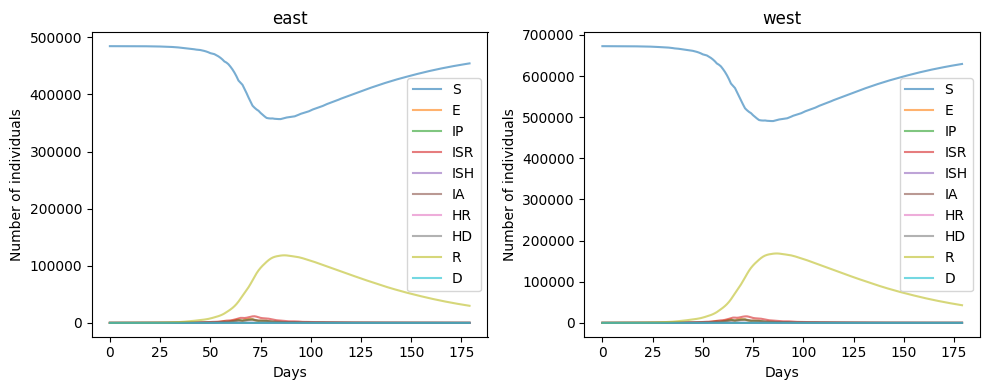

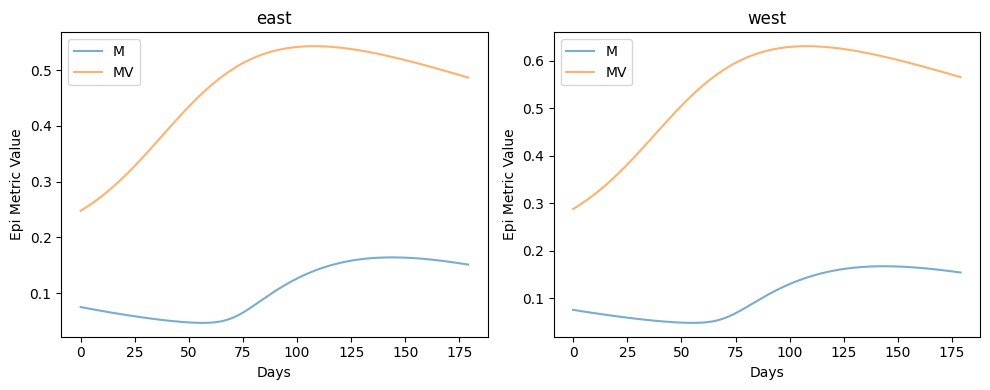

In [13]:
beta_val = 0.05
reset_date_list = ["08_01"]#, "09_01", "10_01", "11_01", "12_01", "01_01", "08_01"]

flu_demo_model = flu.FluMetapopModel([east, west],
                                     mixing_params)

outputs = {}
outputs_east = {}

for reset_date in reset_date_list:
    
    flu_demo_model.reset_simulation()
    
    for subpop_model in flu_demo_model._subpop_models_ordered.values():
        subpop_model.params = clt.updated_dataclass(subpop_model.params, {"beta_baseline": beta_val})
        subpop_model.params = clt.updated_dataclass(subpop_model.params, {"vax_immunity_reset_date_mm_dd": reset_date})
    
        
    # print('\n\n #################### beta:', beta_i)
    # print('new beta east:', flu_demo_model.subpop_models['east'].params.beta_baseline)
    # print('new beta west:', flu_demo_model.subpop_models['west'].params.beta_baseline)
    # print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)
    flu_demo_model.simulate_until_day(180)
    # print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)
    
    # clt.plot_metapop_basic_compartment_history(flu_demo_model)
    
    cumul_metrics_east = get_cumul_metrics(flu_demo_model.subpop_models['east'])
    cumul_metrics_west = get_cumul_metrics(flu_demo_model.subpop_models['west'])
    cumul_metrics_total = {
        k: cumul_metrics_east[k] + cumul_metrics_west[k]
        for k in cumul_metrics_east.keys()
    }
    
    outputs[reset_date] = cumul_metrics_total
    outputs_east[reset_date] = cumul_metrics_east


    print('\n\n#####reset_date:', reset_date)
    clt.plot_metapop_basic_compartment_history(flu_demo_model)
    clt.plot_metapop_epi_metrics(flu_demo_model)
    
    # if np.isclose(beta_i, 0.05): 
    #     clt.plot_metapop_basic_compartment_history(flu_demo_model)

In [14]:
east_model = flu_demo_model.subpop_models['east']
MV_east = east_model.epi_metrics['MV']

all_MV_vals = MV_east.history_vals_list
all_MV_vals

[array([[0.33843338],
        [0.35271978],
        [0.14389847],
        [0.13697637],
        [0.26666415]]),
 array([[0.34153996],
        [0.35530621],
        [0.14489166],
        [0.13899876],
        [0.26976437]]),
 array([[0.3447187 ],
        [0.35793612],
        [0.14590534],
        [0.141116  ],
        [0.27298824]]),
 array([[0.34796942],
        [0.36060842],
        [0.14693947],
        [0.14333083],
        [0.27633731]]),
 array([[0.35129094],
        [0.36332299],
        [0.14799399],
        [0.14564403],
        [0.27981413]]),
 array([[0.35468407],
        [0.36607873],
        [0.14906886],
        [0.14805933],
        [0.28341923]]),
 array([[0.35814765],
        [0.36887553],
        [0.15016501],
        [0.15057748],
        [0.28715516]]),
 array([[0.3616805 ],
        [0.3717123 ],
        [0.1512814 ],
        [0.15320122],
        [0.29102243]]),
 array([[0.36528243],
        [0.37458794],
        [0.15241898],
        [0.15593129],
        [0.29502

In [15]:
outputs_east

{'08_01': {'infected': 209093.58337347512, 'hospitalized': 870.5945472296557}}

## Vary beta value

In [17]:
beta_vals_list = np.concatenate([np.arange(0.03, 0.05, 0.001), np.arange(0.06, 0.2, 0.01)])
# beta_vals_list = [0.1, 1.0, 10.0, 100.0]
beta_vals_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06]
# beta_vals_list = np.arange(0.015, 0.02, 0.0005)
# beta_vals_list = np.arange(0.04, 0.05, 0.0005)
# beta_vals_list = np.arange(0.005, 0.05, 0.005)
# beta_vals_list = [0.02]

flu_demo_model = flu.FluMetapopModel([east, west],
                                     mixing_params)

outputs = {}

for beta_i in beta_vals_list:
    
    flu_demo_model.reset_simulation()
    
    for subpop_model in flu_demo_model._subpop_models_ordered.values():
        subpop_model.params = clt.updated_dataclass(subpop_model.params, {"beta_baseline": beta_i})
    
        
    # print('\n\n #################### beta:', beta_i)
    # print('new beta east:', flu_demo_model.subpop_models['east'].params.beta_baseline)
    # print('new beta west:', flu_demo_model.subpop_models['west'].params.beta_baseline)
    # print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)
    flu_demo_model.simulate_until_day(180)
    # print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)
    
    # clt.plot_metapop_basic_compartment_history(flu_demo_model)
    
    cumul_metrics_east = get_cumul_metrics(flu_demo_model.subpop_models['east'])
    cumul_metrics_west = get_cumul_metrics(flu_demo_model.subpop_models['west'])
    cumul_metrics_total = {
        k: cumul_metrics_east[k] + cumul_metrics_west[k]
        for k in cumul_metrics_east.keys()
    }
    
    outputs[beta_i] = cumul_metrics_total


    # print('\n\n#####beta:', beta_i)
    # clt.plot_metapop_basic_compartment_history(flu_demo_model)
    
    # if np.isclose(beta_i, 0.05): 
    #     clt.plot_metapop_basic_compartment_history(flu_demo_model)

In [18]:
subpop_model = flu_demo_model.subpop_models['east']
for name, compartment in subpop_model.compartments.items():
    # Compute summed history values for each age-risk group
    history_vals_list = [np.sum(age_risk_group_entry) for
                            age_risk_group_entry in compartment.history_vals_list]

In [19]:
name = 'ISR'
compartment = subpop_model.compartments[name]
ISR_history = [np.sum(age_risk_group_entry) for
                            age_risk_group_entry in compartment.history_vals_list]

In [20]:
import torch
torch.nn.functional.softplus(torch.tensor(0.0))

tensor(0.6931)

In [21]:
len(compartment.history_vals_list)

180

In [22]:
compartment.history_vals_list[:5]

[array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.00330245],
        [0.00766398],
        [0.07382824],
        [0.01232682],
        [0.00364447]]),
 array([[0.01889874],
        [0.04219188],
        [0.36280872],
        [0.06188694],
        [0.02062805]]),
 array([[0.04254728],
        [0.08999777],
        [0.63035645],
        [0.11321714],
        [0.04669113]]),
 array([[0.06886062],
        [0.1533005 ],
        [0.92286809],
        [0.17496919],
        [0.07984572]])]

In [23]:
ISR_history

[0.0,
 0.10076596458364122,
 0.5064143321732758,
 0.9228097698361997,
 1.3998441241930333,
 2.3138568050405786,
 3.682966906380893,
 5.620856874642557,
 8.298840707076467,
 11.333769541048254,
 13.307901840383943,
 15.41503733579322,
 20.355911878933792,
 28.04794603148799,
 38.88875177815487,
 53.798851612286995,
 70.42853618246595,
 79.94072869004219,
 89.73330023966075,
 114.5533133629811,
 152.83886960791884,
 205.98318498883506,
 277.3262883483787,
 353.836463117401,
 395.0097608019814,
 436.660218824129,
 545.7538502569156,
 711.356595872306,
 939.4801407215751,
 1209.1905706209845,
 1420.456242624976,
 1529.371041658462,
 1642.2691792006635,
 1955.476508382677,
 2484.746709089816,
 3214.1018086827626,
 4168.305550074928,
 5157.495949811814,
 5600.66515575015,
 5874.824921536975,
 6529.4148500234805,
 7431.70479144437,
 8274.90372974426,
 8706.595610769422,
 9294.837368611123,
 9358.676364757,
 9422.59901931412,
 10518.932970869007,
 12222.81348635103,
 14256.197451567603,
 16481

In [24]:
subpop_model.compartments.keys()

['S', 'E', 'IP', 'ISR', 'ISH', 'IA', 'HR', 'HD', 'R', 'D']

In [25]:
flu_demo_model.subpop_models['west'].transition_variables.S_to_E.history_vals_list

[array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.05358165],
        [0.18356691],
        [1.56475992],
        [0.36290057],
        [0.1340494 ]]),
 array([[0.05358173],
        [0.18357652],
        [1.56499917],
        [0.36294967],
        [0.13406817]]),
 array([[0.05358179],
        [0.18358608],
        [1.56523798],
        [0.36299864],
        [0.13408692]]),
 array([[0.05358184],
        [0.18359557],
        [1.56547633],
        [0.36304749],
        [0.13410564]]),
 array([[0.05358186],
        [0.183605  ],
    

In [26]:
subpop_model = flu_demo_model.subpop_models['west']
np.sum(np.asarray(subpop_model.transition_variables.S_to_E.history_vals_list))

483347.657835127

483347.6578351269


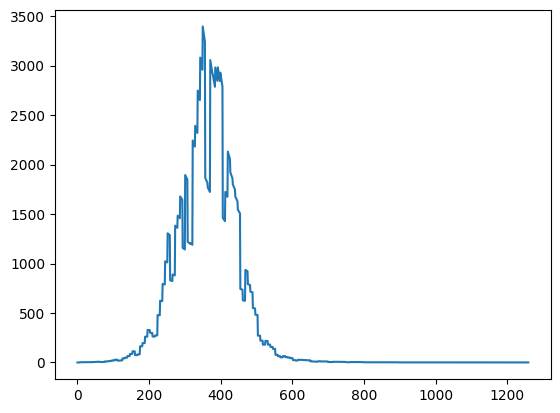

In [27]:
age_sum = [sum(x)[0] for x in west.transition_variables.ISH_to_HR.history_vals_list]
age_sum = [sum(x)[0] for x in west.transition_variables.S_to_E.history_vals_list]
print(sum(age_sum))
plt.plot(age_sum)

In [28]:
np.asarray([1.0, 1.1, 1.25, 1.5, 1.75, 1.9, 2.0], dtype=int)

array([1, 1, 1, 1, 1, 1, 2])

In [29]:
df_output = pd.DataFrame.from_dict(outputs, orient='index')\
    .reset_index()\
    .rename(columns={'index':'beta_baseline'})
df_output

,beta_baseline,infected,hospitalized
0,0.01,10.570687,0.128709
1,0.02,37.037602,0.266082
2,0.03,186.588712,1.033383
3,0.04,138176.859104,597.235568
4,0.05,510438.263658,2316.190887
5,0.06,824507.852195,3757.052585


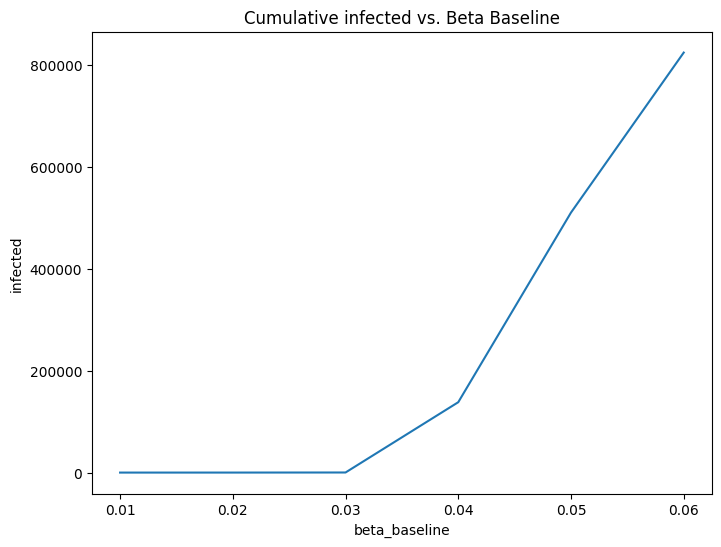

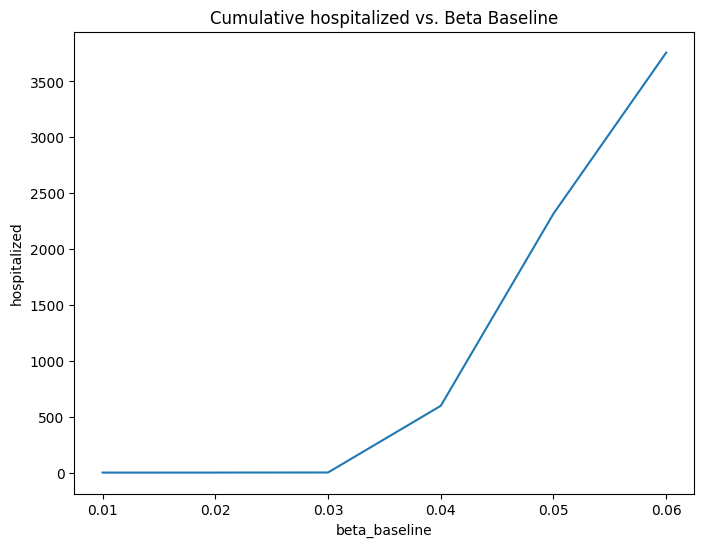

In [30]:
metrics = [
    x for x in df_output.columns if x != 'beta_baseline'
]

for i_metric, metric in enumerate(metrics):
    fig, ax = plt.subplots(1, 1, figsize=(8,6))
    sns.lineplot(
        data=df_output,
        x='beta_baseline',
        y=metric,
        # marker='o',
        ax=ax
    )
    ax.set_title(f'Cumulative {metric} vs. Beta Baseline')
    plt.show()

# Simulation and Analysis

In [35]:
# Get the current real date of the simulation and the
#   current simulation day
print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)

# Simulate for a given number of days
flu_demo_model.simulate_until_day(265)

# Get the current real date of the simulation and the
#   current simulation day
print(flu_demo_model.current_simulation_day, flu_demo_model.current_real_date)

261 2024-06-29


IndexError: index 0 is out of bounds for axis 0 with size 0

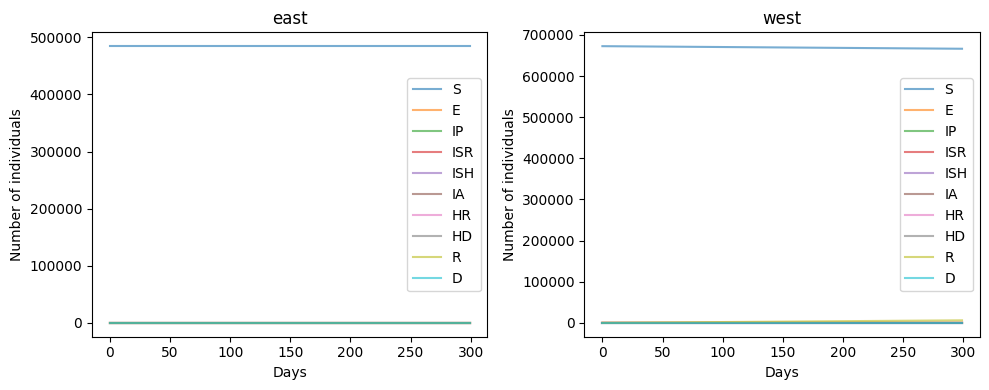

In [7]:
# Generate simple compartment history plot for flu model
clt.plot_metapop_basic_compartment_history(flu_demo_model)

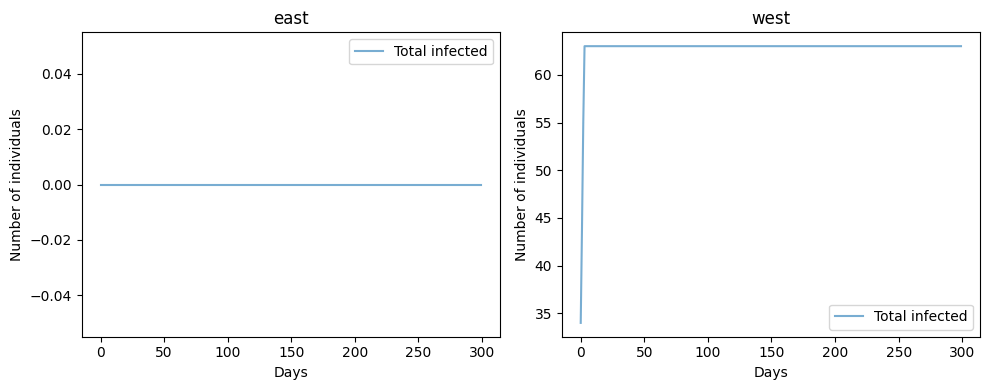

In [8]:
clt.plot_metapop_total_infected(flu_demo_model)


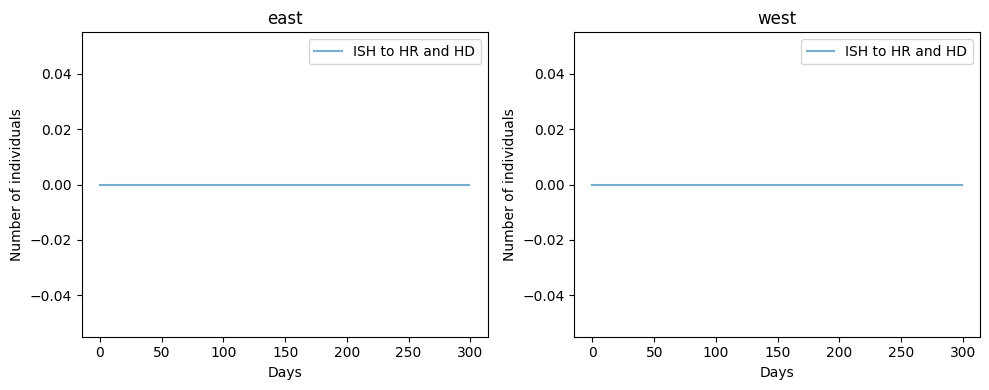

In [9]:
clt.plot_metapop_TransitionVariable(flu_demo_model)

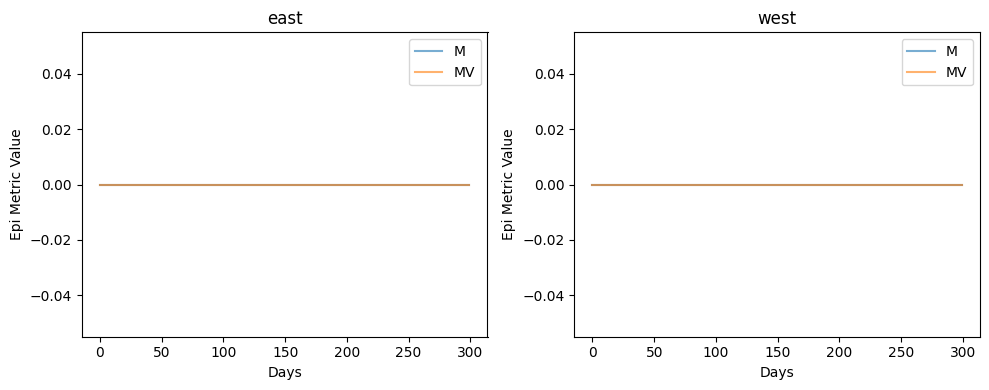

In [10]:
clt.plot_metapop_epi_metrics(flu_demo_model)

In [11]:
# Print the %population exposed for east and west Austin,
# knowing that some individuals are exposed twice since have R to S, many protected by immunity, but possibly not all
print(round(np.sum(np.asarray(east.transition_variables.S_to_E.history_vals_list))/387413,2))
print(round(np.sum(np.asarray(west.transition_variables.S_to_E.history_vals_list))/543134,2))
#print(round(np.sum(np.asarray(east.transition_variables.S_to_E.history_vals_list)),2))
#print(round(np.sum(np.asarray(west.transition_variables.S_to_E.history_vals_list)),2))

0.0
0.01


In [12]:
# Print the per capita number of hospitalizations for east and west Austin
east_IS_to_H = np.asarray(east.transition_variables.ISH_to_HR.history_vals_list) + \
    np.asarray(east.transition_variables.ISH_to_HD.history_vals_list)
west_IS_to_H = np.asarray(west.transition_variables.ISH_to_HR.history_vals_list) + \
    np.asarray(west.transition_variables.ISH_to_HD.history_vals_list)
eastHosp = round(np.sum(east_IS_to_H)/387413*100000)
westHosp = round(np.sum(west_IS_to_H)/543134*100000)
print(eastHosp)
print(westHosp)

0
0


In [13]:
# Compute per capita hospitalization across Austin, weighted average of east and west
# For PHR7, which includes Austin, it was 89.2, flu_instances/texax_flu_hosp_rate_20232024/austin_flu_hosp_rate_20232024
round((eastHosp*387413+westHosp*543134)/(387413+543134))

0

In [14]:
# Timing of infected peak, first for East
# First need to sum over all "I" compartments
infected_compartment_names = [name for name in east.compartments.keys() if "I" in name or "H" in name]
infected_compartments_history = [east.compartments[compartment_name].history_vals_list for compartment_name in infected_compartment_names]
total_infectedE = np.sum(np.asarray(infected_compartments_history), axis=(0, 2, 3))
print(np.argmax(total_infectedE))

# then for West
infected_compartment_names = [name for name in west.compartments.keys() if "I" in name or "H" in name]
infected_compartments_history = [west.compartments[compartment_name].history_vals_list for compartment_name in infected_compartment_names]
total_infectedW = np.sum(np.asarray(infected_compartments_history), axis=(0, 2, 3))
print(np.argmax(total_infectedW))

# and finally total
total_infected = np.asarray(total_infectedE+total_infectedW)
print(np.argmax(total_infectedW))
# Peak hospitalizations was week of 12/30 in Austin and peak 7 day average was day of 1/4 in TX.  Peak infection usually occurs ~2 weeks prior or 12/21 (day 62).
# [Comparing peak ILI and peak in hospitalizations: https://www.cdc.gov/flu/whats-new/flu-summary-2023-2024.html]

#print(np.sum(total_infectedE))
#print(np.sum(total_infectedW))

0
3
3


In [15]:
# Print the % of recovered that become susceptible again for east and west Austin
# It's the same since this is just based on rates of being recovered and going to susceptible, 
#    which is same in two subpopulations
numRtoS_east = np.sum(np.asarray(east.transition_variables.R_to_S.history_vals_list))
numIAtoR_east = np.sum(np.asarray((east.transition_variables.IA_to_R.history_vals_list)))
numISRtoR_east = np.sum(np.asarray((east.transition_variables.ISR_to_R.history_vals_list)))
numHRtoR_east = np.sum(np.asarray((east.transition_variables.HR_to_R.history_vals_list)))
numR_east = numIAtoR_east + numISRtoR_east + numHRtoR_east
#print(round(numRtoS_east/numR_east))

numRtoS_west = np.sum(np.asarray(east.transition_variables.R_to_S.history_vals_list))
numIAtoR_west = np.sum(np.asarray((east.transition_variables.IA_to_R.history_vals_list)))
numISRtoR_west = np.sum(np.asarray((east.transition_variables.ISR_to_R.history_vals_list)))
numHRtoR_west = np.sum(np.asarray((east.transition_variables.HR_to_R.history_vals_list)))
numR_west = numIAtoR_west + numISRtoR_west + numHRtoR_west
#print(round(numRtoS_west/numR_west))

#print(numR_east)
#print(numR_west)

In [16]:
west.epi_metrics.MV.history_vals_list

[array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        